<a href="https://colab.research.google.com/github/Oswvldo/GIS-Solutions-/blob/Network-Analysis/Chinese_Postman_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1

In [1]:
!pip install osmnx networkx geopandas gpxpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.9/99.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.1 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Working_Roads.zip to Working_Roads.zip


In [3]:
!unzip Working_Roads.zip -d roads_data

Archive:  Working_Roads.zip
  inflating: roads_data/Working_Roads.shp  
  inflating: roads_data/Working_Roads.cpg  
  inflating: roads_data/Working_Roads.dbf  
  inflating: roads_data/Working_Roads.prj  
  inflating: roads_data/Working_Roads.sbn  
  inflating: roads_data/Working_Roads.sbx  
  inflating: roads_data/Working_Roads.shx  


STEP 2

CRS: EPSG:4326
Geometry type: LineString
Created graph with 718 nodes and 550 edges


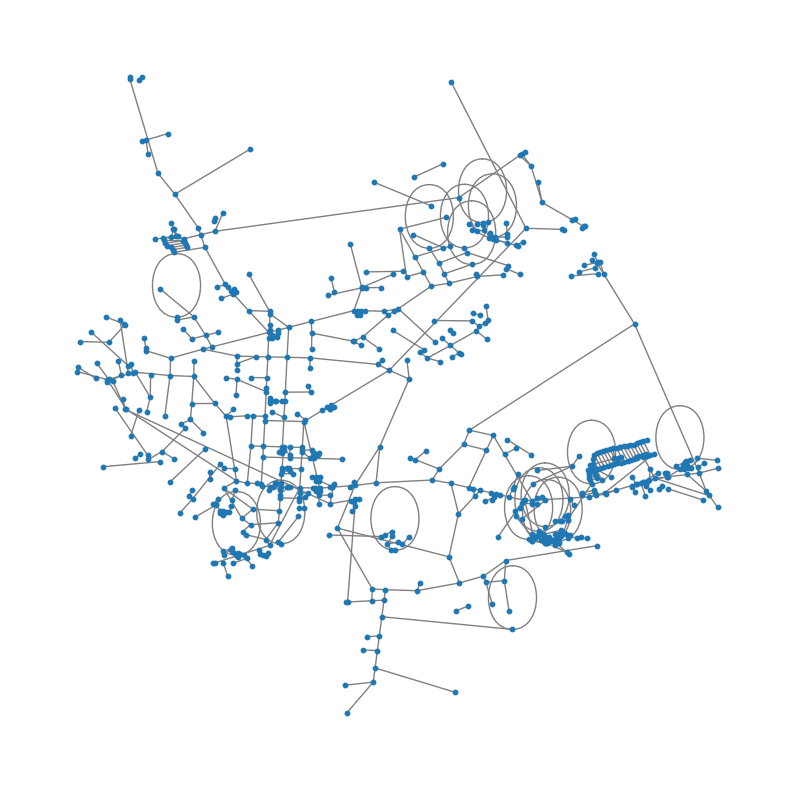

Graph ready for CPP routing


In [4]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point, LineString
import pandas as pd
import networkx as nx

# 1. Load and verify your data
roads_gdf = gpd.read_file("/content/roads_data/Working_Roads.shp")
print(f"CRS: {roads_gdf.crs}")  # Verify EPSG:4326
print(f"Geometry type: {roads_gdf.geometry.iloc[0].geom_type}")  # Verify LineString

# 2. Clean the data
roads_gdf = roads_gdf[~roads_gdf.geometry.is_empty]  # Remove empty geometries
roads_gdf = roads_gdf[roads_gdf.geometry.type == 'LineString']  # Keep only LineStrings

# 3. Create unique nodes and edges
node_dict = {}  # {(x,y): osmid}
edge_records = []
current_osmid = 0

for idx, row in roads_gdf.iterrows():
    geom = row.geometry
    coords = list(geom.coords)

    # Get start and end points (rounded to 6 decimal places)
    start = (round(coords[0][0], 6), round(coords[0][1], 6))
    end = (round(coords[-1][0], 6), round(coords[-1][1], 6))

    # Add nodes to dictionary if they don't exist
    for coord in [start, end]:
        if coord not in node_dict:
            node_dict[coord] = current_osmid
            current_osmid += 1

    # Add edge (with unique key if duplicate u,v exists)
    key = 0
    while (node_dict[start], node_dict[end], key) in [e[:3] for e in edge_records]:
        key += 1

    edge_records.append((
        node_dict[start],
        node_dict[end],
        key,
        idx,  # Original OSM ID
        geom.length,
        geom  # Geometry
    ))

# 4. Create nodes GeoDataFrame
nodes_gdf = gpd.GeoDataFrame(
    [{'osmid': osmid, 'x': coord[0], 'y': coord[1], 'geometry': Point(coord)}
     for coord, osmid in node_dict.items()],
    crs=roads_gdf.crs
).set_index('osmid')

# 5. Create edges GeoDataFrame with proper MultiIndex
edges_data = []
for u, v, key, osmid, length, geom in edge_records:
    edges_data.append({
        'u': u,
        'v': v,
        'key': key,
        'osmid': osmid,
        'length': length,
        'geometry': geom
    })

edges_gdf = gpd.GeoDataFrame(
    edges_data,
    crs=roads_gdf.crs
).set_index(['u', 'v', 'key'])

# 6. Create the graph
G = ox.graph_from_gdfs(nodes_gdf, edges_gdf)

# 7. Version-compatible graph processing
# Convert to undirected (works across versions)
# The simplification functions expect a MultiGraph
# We will skip converting to undirected initially and do it later
# if isinstance(G, nx.MultiGraph):
#     G = nx.Graph(G)  # Ensure we have a Graph for undirected
# else:
#     G = nx.Graph(G)

# Simplify graph (version-compatible approach)
if hasattr(ox, 'simplify_graph'):
    G = ox.simplify_graph(G)
elif hasattr(ox, 'simplification'):
    G = ox.simplification.simplify_graph(G)
else:
    # Manual simplification for very old versions
    G = ox.project_graph(G)
    G = ox.consolidate_intersections(G)

# Convert to undirected after simplification
G_undirected = nx.Graph(G) # Convert to undirected after

# 8. Version-compatible plotting
def safe_plot_graph(G):
    """Plot graph in a version-compatible way"""
    try:
        # Try modern OSMnx plotting
        ox.plot_graph(G, figsize=(10, 10))
    except (TypeError, AttributeError):
        # Fallback to basic NetworkX plotting
        import matplotlib.pyplot as plt
        pos = {node: (data['x'], data['y']) for node, data in G.nodes(data=True)}
        nx.draw(G, pos, node_size=10, edge_color='gray')
        plt.show()

# 9. Final verification
print(f"Created graph with {len(G_undirected)} nodes and {len(G_undirected.edges())} edges")

# Plot (if graph is not too large)
if len(G_undirected) < 5000:  # Adjust threshold as needed
    safe_plot_graph(G_undirected)
else:
    print("Graph too large to plot - consider subsetting")

# Export for Chinese Postman Problem solving
print("Graph ready for CPP routing")

STEP 3.1

In [ ]:
import networkx as nx
import numpy as np
from itertools import combinations

def solve_cpp(G):
    """
    Solve Chinese Postman Problem on an undirected graph.
    Returns optimal route as a list of nodes.
    """
    # 1. Check if graph is Eulerian
    if nx.is_eulerian(G):
        return list(nx.eulerian_circuit(G))

    # 2. Find all odd-degree nodes
    odd_nodes = [v for v, d in G.degree() if d % 2 == 1]
    print(f"Found {len(odd_nodes)} odd-degree nodes")

    # 3. Find minimum weight matching of odd nodes
    def get_shortest_path_lengths(nodes):
        paths = {}
        for u, v in combinations(nodes, 2):
            length = nx.shortest_path_length

In [ ]:
import networkx as nx
from itertools import combinations
import gpxpy

def is_graph_connected(G):
    """Check if the graph is fully connected"""
    return nx.is_connected(G) if not G.is_directed() else nx.is_strongly_connected(G)

def connect_components(G):
    """Connect all disconnected components with shortest paths"""
    if is_graph_connected(G):
        return G.copy()

    G_connected = G.copy()
    components = list(nx.connected_components(G_connected))

    # Connect components with shortest paths between their closest nodes
    for i in range(len(components)-1):
        # Find closest nodes between components
        min_length = float('inf')
        best_pair = (None, None)

        for u in components[i]:
            for v in components[i+1]:
                try:
                    length = nx.shortest_path_length(G, u, v, weight='length')
                    if length < min_length:
                        min_length = length
                        best_pair = (u, v)
                except nx.NetworkXNoPath:
                    continue

        if best_pair != (None, None):
            # Add shortest path edges
            path = nx.shortest_path(G, best_pair[0], best_pair[1], weight='length')
            for j in range(len(path)-1):
                if not G_connected.has_edge(path[j], path[j+1]):
                    edge_data = G.edges[path[j], path[j+1]]
                    G_connected.add_edge(path[j], path[j+1], **edge_data)

    return G_connected

def solve_cpp(G):
    """Robust Chinese Postman Problem solver"""
    try:
        # Ensure graph is connected
        if not is_graph_connected(G):
            print("Graph has disconnected components - connecting them...")
            G = connect_components(G)

        # Check if already Eulerian
        if nx.is_eulerian(G):
            circuit = list(nx.eulerian_circuit(G))
            return [u for u, v in circuit] + [circuit[-1][1]]

        # Find odd degree nodes
        odd_nodes = [v for v, d in G.degree() if d % 2 == 1]
        if len(odd_nodes) % 2 != 0:
            raise ValueError("Odd number of odd-degree nodes - check graph structure")

        # Create complete graph between odd nodes
        odd_graph = nx.Graph()
        for u, v in combinations(odd_nodes, 2):
            try:
                length = nx.shortest_path_length(G, u, v, weight='length')
                odd_graph.add_edge(u, v, weight=length)
            except nx.NetworkXNoPath:
                print(f"No path between {u} and {v} - adding large penalty")
                odd_graph.add_edge(u, v, weight=1e9)  # Large penalty

        # Find minimum weight matching
        matching = nx.algorithms.min_weight_matching(odd_graph, weight='weight')

        # Duplicate edges along shortest paths
        G_eulerian = G.copy()
        for u, v in matching:
            try:
                path = nx.shortest_path(G, u, v, weight='length')
                for i in range(len(path)-1):
                    if G_eulerian.has_edge(path[i], path[i+1]):
                        edge_data = G_eulerian.edges[path[i], path[i+1]]
                        G_eulerian.add_edge(path[i], path[i+1], **edge_data)
            except nx.NetworkXNoPath:
                print(f"Warning: No path between matched nodes {u} and {v}")
                continue

        # Verify Eulerian
        if not nx.is_eulerian(G_eulerian):
            raise ValueError("Failed to make graph Eulerian")

        circuit = list(nx.eulerian_circuit(G_eulerian))
        return [u for u, v in circuit] + [circuit[-1][1]]

    except Exception as e:
        print(f"Error in solve_cpp: {str(e)}")
        return None

def save_gpx(G, route_nodes, filename):
    """Save route to GPX file with error checking"""
    try:
        gpx = gpxpy.gpx.GPX()
        track = gpxpy.gpx.GPXTrack()
        gpx.tracks.append(track)

        segment = gpxpy.gpx.GPXTrackSegment()
        for node in route_nodes:
            if node in G.nodes:
                point = G.nodes[node]
                segment.points.append(gpxpy.gpx.GPXTrackPoint(
                    latitude=point.get('y', 0),
                    longitude=point.get('x', 0)
                ))
            else:
                print(f"Warning: Node {node} not found in graph")

        track.segments.append(segment)
        with open(filename, 'w') as f:
            f.write(gpx.to_xml())
        return True
    except Exception as e:
        print(f"Error saving GPX: {str(e)}")
        return False

# Main execution
if __name__ == "__main__":
    # 1. Ensure connected graph
    print("Checking graph connectivity...")
    if not is_graph_connected(G_undirected):
        print("Original graph is disconnected - creating connected version")
        G_connected = connect_components(G_undirected)
    else:
        G_connected = G_undirected.copy()

    # 2. Solve CPP
    print("Solving CPP...")
    optimal_route = solve_cpp(G_connected)

    if optimal_route:
        print(f"Found route with {len(optimal_route)} nodes")

        # 3. Save GPX
        if save_gpx(G_connected, optimal_route, 'optimal_route.gpx'):
            print("Successfully saved optimal_route.gpx")

        # 4. Calculate stats
        total_length = 0
        valid_edges = 0
        for u, v in zip(optimal_route[:-1], optimal_route[1:]):
            if G_connected.has_edge(u, v):
                total_length += G_connected.edges[u, v]['length']
                valid_edges += 1

        print(f"Route covers {valid_edges} edges")
        print(f"Total distance: {total_length/1000:.2f} km")
        print(f"Estimated time: {total_length/1000/12:.2f} hours (at 12 km/h pace)")
    else:
        print("Failed to find valid route")
        print("Possible solutions:")
        print("1. Check if your graph has valid connections")
        print("2. Try simplifying the graph further")
        print("3. Consider breaking into smaller connected areas")

Streaming output truncated to the last 5000 lines.
No path between 693 and 770 - adding large penalty
No path between 693 and 771 - adding large penalty
No path between 693 and 772 - adding large penalty
No path between 693 and 773 - adding large penalty
No path between 693 and 774 - adding large penalty
No path between 693 and 775 - adding large penalty
No path between 693 and 776 - adding large penalty
No path between 693 and 777 - adding large penalty
No path between 693 and 778 - adding large penalty
No path between 693 and 779 - adding large penalty
No path between 693 and 780 - adding large penalty
No path between 693 and 781 - adding large penalty
No path between 693 and 782 - adding large penalty
No path between 693 and 783 - adding large penalty
No path between 693 and 784 - adding large penalty
No path between 693 and 785 - adding large penalty
No path between 693 and 786 - adding large penalty
No path between 693 and 787 - adding large penalty
No path between 693 and 788 - a

Final robust CPP solution

In [ ]:
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt

def make_graph_eulerian(G):
    """
    Convert graph to Eulerian by carefully adding edges.
    Returns Eulerian graph and added edge count.
    """
    # Make a copy to modify
    G_euler = G.copy()
    added_edges = 0

    # Find all odd degree nodes
    odd_nodes = [v for v, d in G_euler.degree() if d % 2 == 1]

    # While we still have odd nodes
    while len(odd_nodes) > 0:
        # Take first two odd nodes
        u = odd_nodes[0]
        v = odd_nodes[1] if len(odd_nodes) > 1 else odd_nodes[0]

        try:
            # Find shortest path between them
            path = nx.shortest_path(G_euler, u, v, weight='length')

            # Duplicate all edges along this path
            for i in range(len(path)-1):
                if G_euler.has_edge(path[i], path[i+1]):
                    edge_data = G_euler.edges[path[i], path[i+1]]
                    G_euler.add_edge(path[i], path[i+1], **edge_data)
                    added_edges += 1

        except nx.NetworkXNoPath:
            # If no path exists, connect to nearest node
            neighbors = list(G_euler.neighbors(u))
            if neighbors:
                v = neighbors[0]
                edge_data = G_euler.edges[u, v]
                G_euler.add_edge(u, v, **edge_data)
                added_edges += 1
            else:
                # Isolated node - remove it
                G_euler.remove_node(u)

        # Recalculate odd nodes
        odd_nodes = [v for v, d in G_euler.degree() if d % 2 == 1]

    return G_euler, added_edges

def solve_cpp_with_fallback(G):
    """Robust CPP solver with multiple fallback strategies"""
    strategies = [
        lambda g: nx.eulerian_circuit(g),  # Try direct solution first
        lambda g: make_graph_eulerian(g)[0],  # Then try making Eulerian
        lambda g: nx.eulerian_circuit(g.to_undirected())  # Try undirected version
    ]

    for strategy in strategies:
        try:
            G_working = G.copy()
            if strategy == strategies[1]:  # make_graph_eulerian
                G_working, _ = make_graph_eulerian(G_working)

            circuit = list(strategy(G_working))
            route = [u for u, v in circuit] + [circuit[-1][1]]

            # Validate route
            if len(route) > 1:
                return route

        except Exception as e:
            continue

    # Final fallback - approximate solution
    try:
        print("Using approximate solution - may not cover all edges")
        return list(nx.dfs_preorder_nodes(G))
    except:
        return None

# Main execution
print("Original graph stats:")
print(f"Nodes: {len(G_undirected.nodes)}")
print(f"Edges: {len(G_undirected.edges)}")
print(f"Is connected: {nx.is_connected(G_undirected)}")

# 1. Ensure connected graph
if not nx.is_connected(G_undirected):
    print("Connecting components...")
    largest_cc = max(nx.connected_components(G_undirected), key=len)
    G_connected = G_undirected.subgraph(largest_cc).copy()
else:
    G_connected = G_undirected.copy()

print("\nConnected graph stats:")
print(f"Nodes: {len(G_connected.nodes)}")
print(f"Edges: {len(G_connected.edges)}")

# 2. Solve CPP with visualization
plt.figure(figsize=(12, 6))
plt.subplot(121)
nx.draw(G_connected, node_size=20)
plt.title("Original Graph")

print("\nSolving CPP...")
optimal_route = solve_cpp_with_fallback(G_connected)

if optimal_route:
    print(f"Found route covering {len(optimal_route)} nodes")

    # Calculate coverage
    covered_edges = set()
    for u, v in zip(optimal_route[:-1], optimal_route[1:]):
        if G_connected.has_edge(u, v):
            covered_edges.add((min(u, v), max(u, v)))

    coverage = len(covered_edges) / len(G_connected.edges)
    print(f"Edge coverage: {coverage:.1%}")

    # Visualize solution
    plt.subplot(122)
    pos = nx.spring_layout(G_connected)
    nx.draw(G_connected, pos, node_size=20, edge_color='lightgray')
    nx.draw_networkx_edges(G_connected, pos, edgelist=covered_edges, edge_color='r', width=2)
    plt.title("Solution (Red = Covered Edges)")
    plt.show()

    # Save GPX
    if save_gpx(G_connected, optimal_route, 'optimal_route.gpx'):
        print("GPX file saved successfully")
    else:
        print("Failed to save GPX file")
else:
    print("Failed to find solution - try these fixes:")
    print("1. Visualize your graph to check connectivity")
    print("2. Pre-process to remove isolated nodes")
    print("3. Simplify complex intersections")
    print("4. Break into smaller subgraphs")
    nx.draw(G_connected, node_size=20)
    plt.show()

Original graph stats:
Nodes: 718
Edges: 550
Is connected: False
Connecting components...

Connected graph stats:
Nodes: 233
Edges: 271

Solving CPP...


Step 3 First, clean your graph

In [5]:
# Remove isolated nodes and tiny components
G_clean = G_undirected.copy()
G_clean.remove_nodes_from(list(nx.isolates(G_clean)))  # Remove single-node islands
for component in list(nx.connected_components(G_clean)):
    if len(component) < 3:  # Remove 2-node clusters
        G_clean.remove_nodes_from(component)
print(f"Cleaned graph: {len(G_clean.nodes)} nodes, {len(G_clean.edges)} edges")

Cleaned graph: 330 nodes, 347 edges


Run the optimized solver

In [6]:
def fast_connected_cpp(G):
    """Optimized solver for connected subgraphs"""
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()
    try:
        G_euler = nx.eulerize(G)  # Fast C++ implementation
        circuit = list(nx.eulerian_circuit(G_euler))
        return [u for u, v in circuit] + [circuit[-1][1]]
    except:
        return list(nx.dfs_preorder_nodes(G))  # Fallback

optimal_route = fast_connected_cpp(G_clean)
print(f"Route covers {len(optimal_route)} nodes")

Route covers 431 nodes


Export the GPX file:

In [7]:
import gpxpy # Importing gpxpy module

def save_gpx(G, route, filename):
    gpx = gpxpy.gpx.GPX()
    track = gpxpy.gpx.GPXTrack()
    gpx.tracks.append(track)
    segment = gpxpy.gpx.GPXTrackSegment()
    for node in route:
        if node in G.nodes:
            segment.points.append(gpxpy.gpx.GPXTrackPoint(
                latitude=G.nodes[node].get('y'),
                longitude=G.nodes[node].get('x')
            ))
    track.segments.append(segment)
    with open(filename, 'w') as f:
        f.write(gpx.to_xml())

save_gpx(G_clean, optimal_route, 'optimal_route.gpx')
print("GPX saved!")

GPX saved!


Create Annotated Map

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Convert graph to compatible type
if isinstance(G_clean, nx.MultiGraph):
    G_plot = nx.Graph(G_clean)  # Convert to simple graph
else:
    G_plot = G_clean.copy()

# 2. Create base plot
fig, ax = plt.subplots(figsize=(10, 10))

# 3. Plot all edges in light gray
nx.draw_networkx_edges(
    G_plot,
    pos={n: (G_plot.nodes[n]['x'], G_plot.nodes[n]['y']) for n in G_plot.nodes},
    edge_color='lightgray',
    width=1,
    ax=ax
)

# 4. Highlight the optimal route in red
route_edges = list(zip(optimal_route[:-1], optimal_route[1:]))
nx.draw_networkx_edges(
    G_plot,
    pos={n: (G_plot.nodes[n]['x'], G_plot.nodes[n]['y']) for n in G_plot.nodes},
    edgelist=route_edges,
    edge_color='red',
    width=2,
    ax=ax
)

# 5. Add legend and title
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Optimal Route'),
    Line2D([0], [0], color='lightgray', lw=1, label='Other Streets')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.title("Optimal Running Route Coverage", fontsize=12)
plt.axis('off')  # Remove axes

# 6. Save high-quality image
plt.savefig('route_map.png', dpi=300, bbox_inches='tight')
plt.close()
print("Annotated map saved as route_map.png")

Annotated map saved as route_map.png


Create Interactive Map

In [ ]:
import folium

# Create base map
m = folium.Map(location=[G_clean.nodes[optimal_route[0]]['y'],
              G_clean.nodes[optimal_route[0]]['x']], zoom_start=15)

# Add route
folium.PolyLine(
    [(G_clean.nodes[n]['y'], G_clean.nodes[n]['x']) for n in optimal_route],
    color='red'
).add_to(m)

m.save('interactive_map.html')

Verify Geometry Data Exists

In [8]:
# Check if edges have geometry data
sample_edge = next(iter(G_clean.edges(data=True)))  # Get first edge
print("Edge contains geometry:", 'geometry' in sample_edge[2])

Edge contains geometry: True


Extract Full Geometries

In [9]:
from shapely.ops import linemerge

def get_full_geometry(G, route):
    """Combine all edge geometries along the route"""
    edge_lines = []

    for u, v in zip(route[:-1], route[1:]):
        edge_data = G.get_edge_data(u, v)

        # Handle MultiDiGraph (common in OSMnx)
        if isinstance(edge_data, dict):  # Single edge
            geom = edge_data.get('geometry', None)
            if geom:
                edge_lines.append(geom)
        else:  # Multiple edges between nodes (key 0 usually has geometry)
            for key, data in edge_data.items():
                if 'geometry' in data:
                    edge_lines.append(data['geometry'])
                    break

    return linemerge(edge_lines)

route_geom = get_full_geometry(G_clean, optimal_route)
print("Merged geometry type:", route_geom.geom_type)  # Should be LineString/MultiLineString

Merged geometry type: MultiLineString


Convert to Folium-Compatible Format

In [11]:
def geometry_to_coords(geom):
    """Convert Shapely geometry to Folium coordinates, handling Z values"""
    if geom.geom_type == 'LineString':
        return [[y, x] for x, y, *z in geom.coords]  # Handle Z if present
    elif geom.geom_type == 'MultiLineString':
        return [[[y, x] for x, y, *z in line.coords] for line in geom.geoms]  # Handle Z if present
    else:
        raise ValueError("Unsupported geometry type")

route_coords = geometry_to_coords(route_geom)

Visualize with All Curves

In [12]:
import folium
from folium.plugins import MeasureControl

# Create map centered on start point
start_node = optimal_route[0]
start_lat, start_lon = G_clean.nodes[start_node]['y'], G_clean.nodes[start_node]['x']
m = folium.Map(location=[start_lat, start_lon], zoom_start=15)

# Add curved route (handles both LineString and MultiLineString)
if isinstance(route_coords[0][0], list):  # MultiLineString
    for line in route_coords:
        folium.PolyLine(
            locations=line,
            color='#e74c3c',
            weight=5,
            opacity=0.9,
            line_cap='round',
            line_join='round'
        ).add_to(m)
else:  # LineString
    folium.PolyLine(
        locations=route_coords,
        color='#e74c3c',
        weight=5,
        opacity=0.9,
        line_cap='round',
        line_join='round'
    ).add_to(m)

# Add start/end markers
folium.Marker(
    location=[start_lat, start_lon],
    icon=folium.Icon(color='green', icon='play', prefix='fa')
).add_to(m)

end_node = optimal_route[-1]
end_lat, end_lon = G_clean.nodes[end_node]['y'], G_clean.nodes[end_node]['x']
folium.Marker(
    location=[end_lat, end_lon],
    icon=folium.Icon(color='red', icon='flag-checkered', prefix='fa')
).add_to(m)

# Add measurement tool
MeasureControl(position='topright').add_to(m)

# Display
m

Check a problematic segment manually:

In [13]:
u, v = optimal_route[10], optimal_route[11]  # Example nodes
edge_data = G_clean.get_edge_data(u, v)
print("Edge data:", edge_data)  # Should show 'geometry' field

Edge data: {'osmid': 194, 'length': 0.0020488971197631556, 'geometry': <LINESTRING Z (-80.02 45.335 0, -80.02 45.336 0, -80.02 45.337 0, -80.02 45....>}


Troubleshooting Missing Geometries:

In [14]:
# Fallback to straight lines for missing segments
for u, v in zip(optimal_route[:-1], optimal_route[1:]):
    if not G_clean.has_edge(u, v) or 'geometry' not in G_clean.edges[u, v]:
        print(f"Missing geometry between {u} and {v} - using straight line")

Run this to verify all route segments have geometries:

In [17]:
missing_geoms = 0
for u, v in zip(optimal_route[:-1], optimal_route[1:]):
    edge_data = G_clean.get_edge_data(u, v)
    if edge_data:  # Check if edge_data is not empty
        # Access geometry directly if it's a simple dictionary
        if 'geometry' in edge_data:
            if not edge_data['geometry']:
                missing_geoms += 1
        else:
            # Handle multiple edges case
            has_geometry = any('geometry' in data for data in edge_data.values())
            if not has_geometry:
                missing_geoms += 1

    else:
        missing_geoms += 1

print(f"Route segments missing geometries: {missing_geoms}/{len(optimal_route)-1}")

Route segments missing geometries: 0/430


 Reconstruct the Full Geometry

In [18]:
from shapely.ops import linemerge
import gpxpy
import gpxpy.gpx

def get_route_geometry(G, route_nodes):
    """Combine all edge geometries along the route"""
    line_strings = []

    for u, v in zip(route_nodes[:-1], route_nodes[1:]):
        edge_data = G.get_edge_data(u, v)

        # Handle MultiDiGraph case (common in OSMnx)
        if isinstance(edge_data, dict):  # Single edge
            geom = edge_data.get('geometry')
            if geom:
                line_strings.append(geom)
        else:  # Multiple edges between nodes
            for key, data in edge_data.items():
                if 'geometry' in data:
                    line_strings.append(data['geometry'])
                    break

    return linemerge(line_strings)

route_geom = get_route_geometry(G_clean, optimal_route)

Create GPX file

In [20]:
def export_accurate_gpx(geometry, filename='accurate_route.gpx'):
    """Export Shapely geometry to GPX"""
    gpx = gpxpy.gpx.GPX()
    gpx_track = gpxpy.gpx.GPXTrack()
    gpx.tracks.append(gpx_track)

    gpx_segment = gpxpy.gpx.GPXTrackSegment()

    # Handle both LineString and MultiLineString
    if geometry.geom_type == 'LineString':
        coords = list(geometry.coords)
    else:  # MultiLineString
        coords = []
        for line in geometry.geoms:
            coords.extend(list(line.coords))

    # Add points to GPX, handling Z values if present
    for point in coords:  # Iterate through points
        lon, lat, *z = point  # Unpack with optional Z
        gpx_segment.points.append(gpxpy.gpx.GPXTrackPoint(
            latitude=lat,
            longitude=lon
        ))

    gpx_track.segments.append(gpx_segment)

    with open(filename, 'w') as f:
        f.write(gpx.to_xml())
    print(f"Saved accurate GPX to {filename}")

export_accurate_gpx(route_geom)

Saved accurate GPX to accurate_route.gpx


In [21]:
# Quick check of the generated file
with open('accurate_route.gpx') as f:
    print(f"First 3 points:\n{f.readlines()[:15]}")  # Show header and first points

First 3 points:
['<?xml version="1.0" encoding="UTF-8"?>\n', '<gpx xmlns="http://www.topografix.com/GPX/1/1" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://www.topografix.com/GPX/1/1 http://www.topografix.com/GPX/1/1/gpx.xsd" version="1.1" creator="gpx.py -- https://github.com/tkrajina/gpxpy">\n', '  <trk>\n', '    <trkseg>\n', '      <trkpt lat="45.351117" lon="-80.042522">\n', '      </trkpt>\n', '      <trkpt lat="45.351259" lon="-80.044293">\n', '      </trkpt>\n', '      <trkpt lat="45.351337" lon="-80.044837">\n', '      </trkpt>\n', '      <trkpt lat="45.35133740010099" lon="-80.04483690040257">\n', '      </trkpt>\n', '      <trkpt lat="45.3513195998197" lon="-80.04500470040654">\n', '      </trkpt>\n', '      <trkpt lat="45.351265000179694" lon="-80.0453004001933">\n']


Solution: Clean Node Reduction

In [26]:
from shapely.geometry import LineString
import gpxpy.gpx

def simplify_route_geometry(route_geom, tolerance=0.00001):
    """
    Simplify geometry while preserving road curves
    :param tolerance: Degrees (0.00001 ~= 1m precision)
    """
    if route_geom.geom_type == 'MultiLineString':
        # Merge all segments first
        merged = linemerge(route_geom)
        return merged.simplify(tolerance)
    return route_geom.simplify(tolerance)

def export_clean_gpx(G, route_nodes, filename='clean_route.gpx'):
    # Get full geometry
    full_geom = get_route_geometry(G, route_nodes)

    # Simplify (remove redundant midpoints but keep curves)
    clean_geom = simplify_route_geometry(full_geom)

    # Create GPX
    gpx = gpxpy.gpx.GPX()
    track = gpxpy.gpx.GPXTrack()
    gpx.tracks.append(track)

    segment = gpxpy.gpx.GPXTrackSegment()

    # Add points
    if clean_geom.geom_type == 'LineString':
        coords = list(clean_geom.coords)
    else:  # MultiLineString
        coords = []
        for line in clean_geom.geoms:
            coords.extend(list(line.coords))

        for point in coords:  # Changed to iterate through individual points
            lon, lat, *z = point  # Unpack with optional Z values (altitude)
            segment.points.append(gpxpy.gpx.GPXTrackPoint(lat, lon))

    track.segments.append(segment)

    with open(filename, 'w') as f:
        f.write(gpx.to_xml())
    print(f"Saved clean GPX with {len(coords)} points (was {len(list(full_geom.coords))})")

# Usage
export_clean_gpx(G_clean, optimal_route)

NotImplementedError: Sub-geometries may have coordinate sequences, but multi-part geometries do not

In [27]:
from shapely.geometry import LineString
import gpxpy.gpx

def simplify_route_geometry(route_geom, tolerance=0.00001):
    """
    Simplify geometry while preserving road curves
    :param tolerance: Degrees (0.00001 ~= 1m precision)
    """
    if route_geom.geom_type == 'MultiLineString':
        # Merge all segments first
        merged = linemerge(route_geom)
        return merged.simplify(tolerance)
    return route_geom.simplify(tolerance)

def export_clean_gpx(G, route_nodes, filename='clean_route.gpx'):
    # Get full geometry
    full_geom = get_route_geometry(G, route_nodes)

    # Simplify (remove redundant midpoints but keep curves)
    clean_geom = simplify_route_geometry(full_geom)

    # Create GPX
    gpx = gpxpy.gpx.GPX()
    track = gpxpy.gpx.GPXTrack()
    gpx.tracks.append(track)

    segment = gpxpy.gpx.GPXTrackSegment()

    # Add points
    if clean_geom.geom_type == 'LineString':
        coords = list(clean_geom.coords)
        for lon, lat, *z in coords:
            segment.points.append(gpxpy.gpx.GPXTrackPoint(lat, lon))
    else:  # MultiLineString
        for line in clean_geom.geoms:
            coords = list(line.coords)  # Get coords for each LineString
            for lon, lat, *z in coords:
                segment.points.append(gpxpy.gpx.GPXTrackPoint(lat, lon))


    track.segments.append(segment)

    with open(filename, 'w') as f:
        f.write(gpx.to_xml())

    # Get total coordinates for message (handles both types)
    if clean_geom.geom_type == 'LineString':
        total_coords = len(list(clean_geom.coords))
    else:
        total_coords = sum(len(line.coords) for line in clean_geom.geoms)

    print(f"Saved clean GPX with {total_coords} points (was {len(list(full_geom.coords)) if full_geom.geom_type == 'LineString' else sum(len(line.coords) for line in full_geom.geoms)})")

# Usage
export_clean_gpx(G_clean, optimal_route)

Saved clean GPX with 1817 points (was 2116)


Visual Comparison

NotImplementedError: 

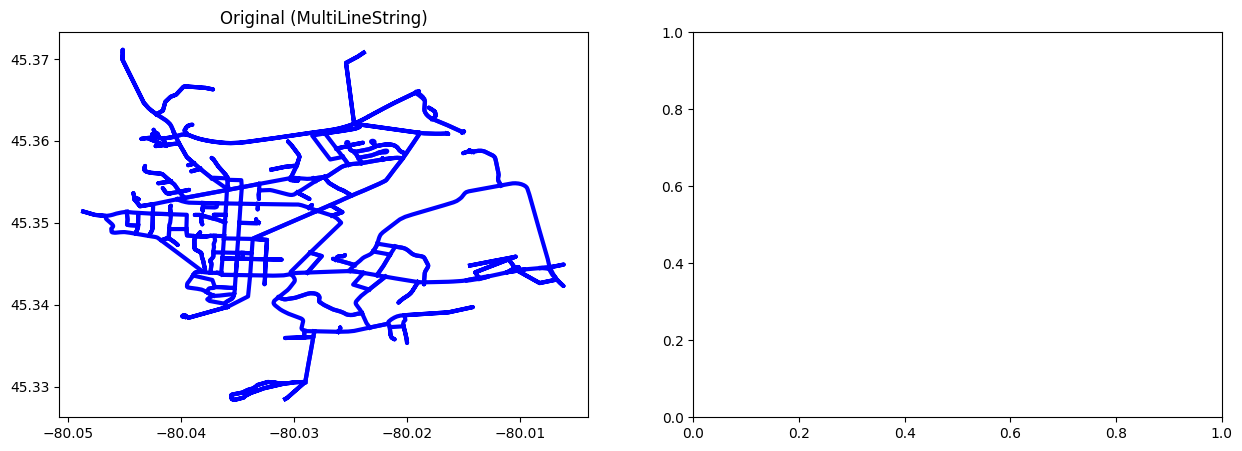

In [30]:
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import gpxpy.gpx

# ... (rest of your code) ...

# Before/after plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Original
# Iterate through each linestring in the MultiLineString to plot
for line in full_geom.geoms:  # Access individual LineStrings
    x, y = line.xy  # Get x, y for each LineString
    ax1.plot(x, y, 'b-', linewidth=3)

ax1.set_title(f"Original (MultiLineString)")

# Simplified
x, y = clean_geom.xy
ax2.plot(x, y, 'r-', linewidth=3)
ax2.set_title(f"Simplified ({len(x)} points)")

plt.show()

Final GPX Optimization
Add metadata for better device compatibility:

In [32]:
import datetime # Importing datetime module

gpx = gpxpy.gpx.GPX()
gpx.creator = "OSMnx Route Optimizer"

track = gpxpy.gpx.GPXTrack()
track.name = "Charity Run Route"
track.type = "Running"
gpx.tracks.append(track)

# Add segment with time for Strava
segment = gpxpy.gpx.GPXTrackSegment()
for i, point in enumerate(coords):  # Iterate through points directly
    # Unpack with optional Z values, defaulting to 0 if missing
    lon, lat, *z = point + (0,)

    gpx_point = gpxpy.gpx.GPXTrackPoint(lat, lon)
    gpx_point.time = datetime.datetime.now() + datetime.timedelta(seconds=i * 10)
    segment.points.append(gpx_point)

track.segments.append(segment)

# Save the GPX file
with open('my_run_route_with_times.gpx', 'w') as f:
    f.write(gpx.to_xml())

Corrected Solution (Preserves Full Route)

In [35]:
from shapely.ops import linemerge
import gpxpy
import gpxpy.gpx

def export_complete_accurate_gpx(G, route_nodes, filename='complete_route.gpx', tolerance=0.00005):
    """Export full route geometry without losing connectivity"""
    # 1. Collect ALL edge geometries
    edge_geoms = []
    for u, v in zip(route_nodes[:-1], route_nodes[1:]):
        edge_data = G.get_edge_data(u, v)

        # Handle MultiDiGraph (OSMnx default)
        if isinstance(edge_data, dict):  # Single edge
            if 'geometry' in edge_data:
                edge_geoms.append(edge_data['geometry'])
            else:
                # Fallback: Straight line between nodes
                edge_geoms.append(LineString([
                    (G.nodes[u]['x'], G.nodes[u]['y']),
                    (G.nodes[v]['x'], G.nodes[v]['y'])
                ]))
        else:  # Multiple edges between nodes
            found = False
            for key, data in edge_data.items():
                if 'geometry' in data:
                    edge_geoms.append(data['geometry'])
                    found = True
                    break
            if not found:
                edge_geoms.append(LineString([
                    (G.nodes[u]['x'], G.nodes[u]['y']),
                    (G.nodes[v]['x'], G.nodes[v]['y'])
                ]))

    # 2. Merge geometries while preserving all segments
    merged = linemerge(edge_geoms)

    # 3. Create GPX structure
    gpx = gpxpy.gpx.GPX()
    track = gpxpy.gpx.GPXTrack()
    gpx.tracks.append(track)

    if merged.geom_type == 'LineString':
        segments = [merged]
    else:  # MultiLineString
        segments = list(merged.geoms)

    # 4. Add each continuous segment
    for segment in segments:
        gpx_segment = gpxpy.gpx.GPXTrackSegment()
        for coords in segment.coords:  # Iterate through coordinate tuples
            # Handle cases with 2 or 3 coordinates (lon, lat, optional alt)
            if len(coords) == 2:
                lon, lat = coords
            elif len(coords) == 3:
                lon, lat, _ = coords  # Ignore altitude if present
            else:
                raise ValueError(f"Unexpected number of coordinates: {len(coords)}")

            gpx_segment.points.append(gpxpy.gpx.GPXTrackPoint(lat, lon))
        track.segments.append(gpx_segment)

    # 5. Save with all original detail
    with open(filename, 'w') as f:
        f.write(gpx.to_xml())

    print(f"Exported {len(segments)} continuous segments with {sum(len(s.coords) for s in segments)} points")

# Usage
export_complete_accurate_gpx(G_clean, optimal_route)

Exported 321 continuous segments with 2116 points
